In [573]:
import pandas as pd
from matplotlib import pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from statsmodels.tsa.stattools import adfuller, kpss

In [574]:
dataset = pd.read_csv("Data/Dataset 2.csv")
dataset.head(1)

,observation_date,UNRATE
0,1948-01-01,3.4


### 1. Data Preparation 
- Check the time index for duplicates, missing timestamps, and irregularities. 
- Check for missing observations and explain how they are handled. 
- Check for obvious data-quality issues and document any preprocessing. 
- Ensure that the observations are correctly ordered chronologically. 
- If a transformation is applied, explain why it is appropriate.

In [575]:
print(f"Number of duplicated rows: {dataset.duplicated().sum()}")
print(f"Number of empty rows: {dataset.isna().values.sum()}")

for column in dataset.columns:
    
    print(f"Data type of '{column}' column: {dataset[column].dtype}")

Number of duplicated rows: 0
Number of empty rows: 1
Data type of 'observation_date' column: object
Data type of 'UNRATE' column: float64


In [576]:
dataset.describe()

,UNRATE
count,942.000000
mean,5.656157
std,1.703930
min,2.500000
25%,4.300000
50%,5.500000
75%,6.700000
max,14.800000


In [577]:
new_names = {}

for column in dataset.columns:
    
    new_names[column] = column.lower()
    
dataset = dataset.rename(columns = new_names)

In [578]:
dataset["observation_date"] = pd.to_datetime(dataset["observation_date"])
dataset["unrate"] = dataset["unrate"].astype("float32").round(1)

In [579]:
dataset = dataset.set_index("observation_date" , drop = True)
dataset.head()

,unrate
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


In [580]:
dataset = dataset.dropna()

In [581]:
print(f"Number of duplicated rows: {dataset.duplicated().sum()}")
print(f"Number of empty rows: {dataset.isna().values.sum()}")

for column in dataset.columns:
    
    print(f"Data type of '{column}' column: {dataset[column].dtype}")
    
print(f"Data type of 'observation_date' column: {dataset.index.dtype}")

Number of duplicated rows: 859
Number of empty rows: 0
Data type of 'unrate' column: float32
Data type of 'observation_date' column: datetime64[ns]


#### Summary

- Loaded the `UNRATE` (unemployment rate) dataset from CSV and previewed its structure.
- Checked for duplicate rows and missing values, and inspected column data types.
- Used `describe()` to review summary statistics and check for obvious data-quality issues (e.g., out-of-range values).
- Standardized column names to lowercase.
- Converted `observation_date` to `datetime` and `unrate` to `float32` (rounded to 1 decimal) to ensure correct, consistent data types.
- Set `observation_date` as the index so the data is properly ordered as a time series.
- Dropped remaining missing observations.
- Re-verified the cleaned data: no duplicates, no missing values, and correct data types for both the date index and the `unrate` column.

The dataset is now cleaned, chronologically indexed, and ready for further time-series analysis.

### 2. Exploratory Time Series Analysis 
- Plot the original time series. 
- Investigate the series for the components we discussed in the sessions. 
- Use appropriate rolling statistics when useful. 
- Use ACF and PACF plots to investigate temporal dependence.

In [ ]:
def plot_series(dataset: pd.DataFrame , column: str , title: str , color: str = "blue") -> None:
    
    plt.figure(figsize = (12 , 4))
    plt.plot(dataset[column] , color = color)
    plt.title(title)
    plt.xlabel(dataset.index.name if dataset.index.name else "Date")
    plt.ylabel(column)
    plt.tight_layout()
    plt.show()

In [583]:
def plot_acf_pacf(dataset: pd.DataFrame , column: str , lags = 30):
    
    fig , axes = plt.subplots(1 , 2 , figsize = (12 , 4))    
    plot_acf(dataset[column].dropna() , lags = lags , ax = axes[0] , zero = False)    
    plot_pacf(dataset[column].dropna() ,lags = lags , ax = axes[1] , method = "ywm" , zero = False)    
    plt.tight_layout()
    plt.show()

In [584]:
def test_stationarity(dataset: pd.DataFrame , column: str):

    adf_pvalue = adfuller(dataset[column].dropna())[1]
    kpss_pvalue = kpss(dataset[column].dropna() , regression = "c" , nlags = "auto")[1]

    adf_stationary = adf_pvalue < 0.05     
    kpss_stationary = kpss_pvalue >= 0.05   

    print("ADF:", "Yes" if adf_stationary else "No")
    print("KPSS:", "Yes" if kpss_stationary else "No")

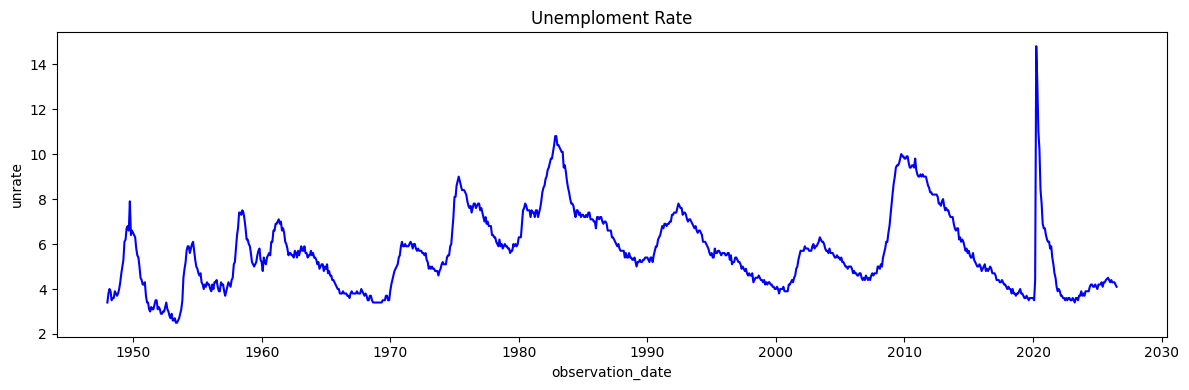

In [585]:
plot_series(dataset , "unrate" , "Unemploment Rate")

In [586]:
test_stationarity(dataset , "unrate")

ADF: Yes
KPSS: Yes


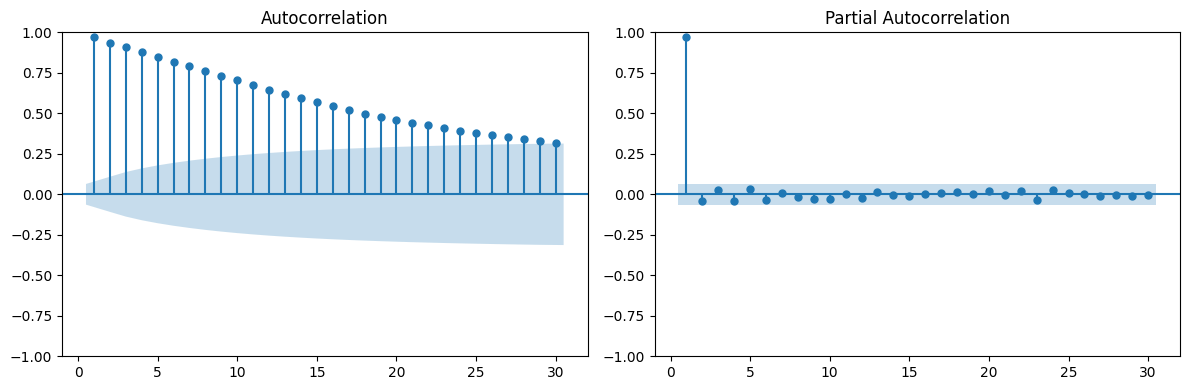

In [587]:
plot_acf_pacf(dataset , "unrate")

| Component     | Present? |
|---------------|----------|
| Trend         | No       |
| Seasonality   | No       |
| White Noise   | No       |

### 3. Smoothing 
- Apply at least two smoothing approaches covered in the course. 
- Explain what the smoothing reveals about the underlying behavior of the series. 
- Discuss any information that may be lost as a result of smoothing. 

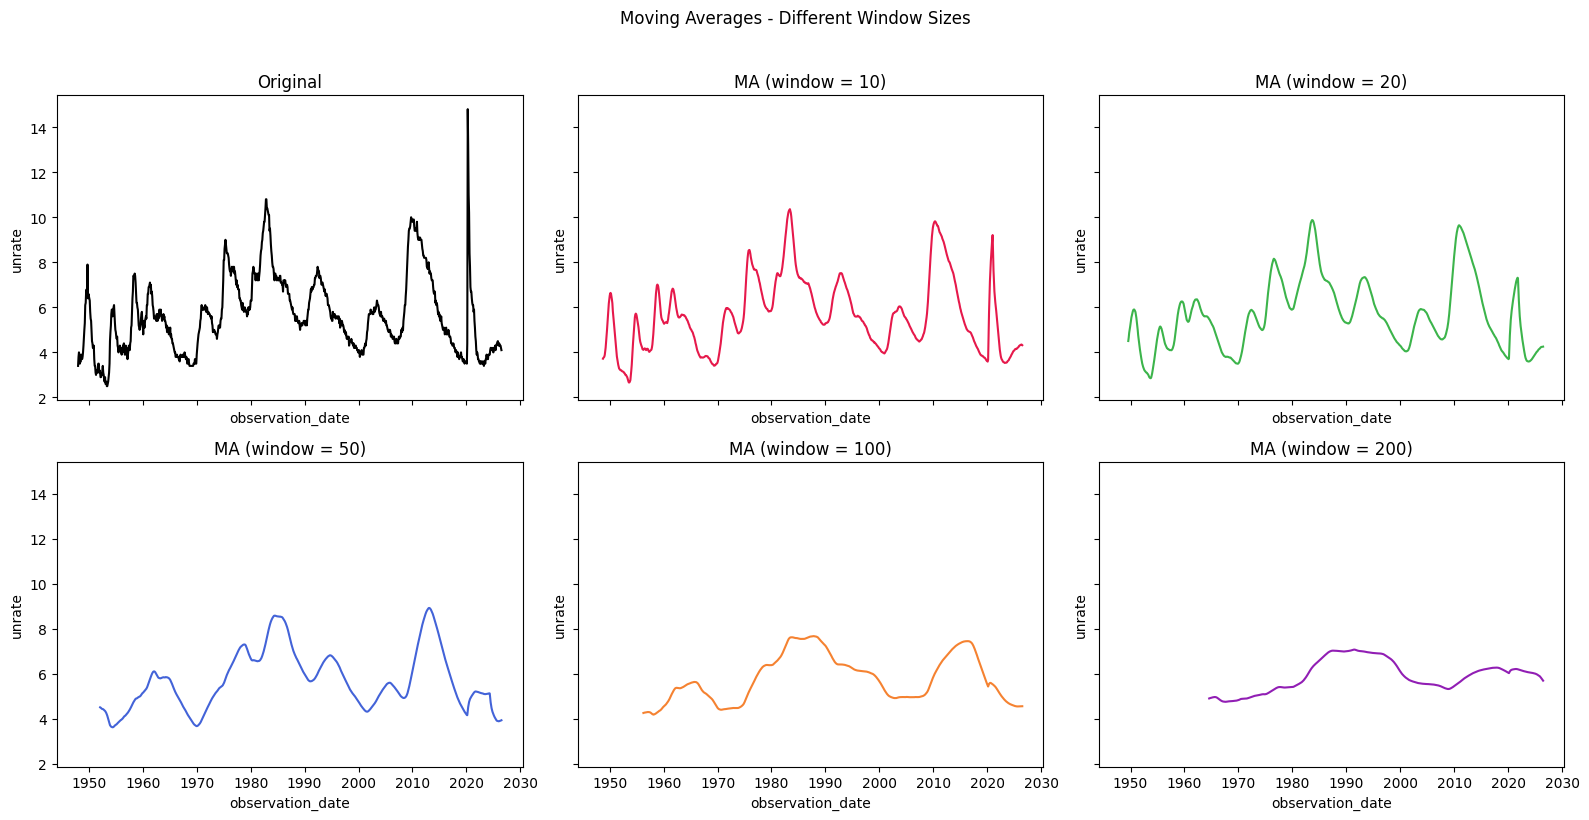

In [606]:
window_sizes = [10, 20, 50, 100, 200]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

# First subplot: original series
axes[0].plot(dataset["unrate"], color="black")
axes[0].set_title("Original")

colors = ["#e6194B", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]

for ax, window_size, color in zip(axes[1:], window_sizes, colors):
    moving_avg = dataset["unrate"].rolling(window_size).mean()
    ax.plot(moving_avg, color=color)
    ax.set_title(f"MA (window = {window_size})")

for ax in axes:
    ax.set_xlabel(dataset.index.name if dataset.index.name else "Date")
    ax.set_ylabel("unrate")

fig.suptitle("Moving Averages - Different Window Sizes", y=1.02)
plt.tight_layout()
plt.show()

c:\Users\Sky Hawk\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sky Hawk\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sky Hawk\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Sky Hawk\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index 

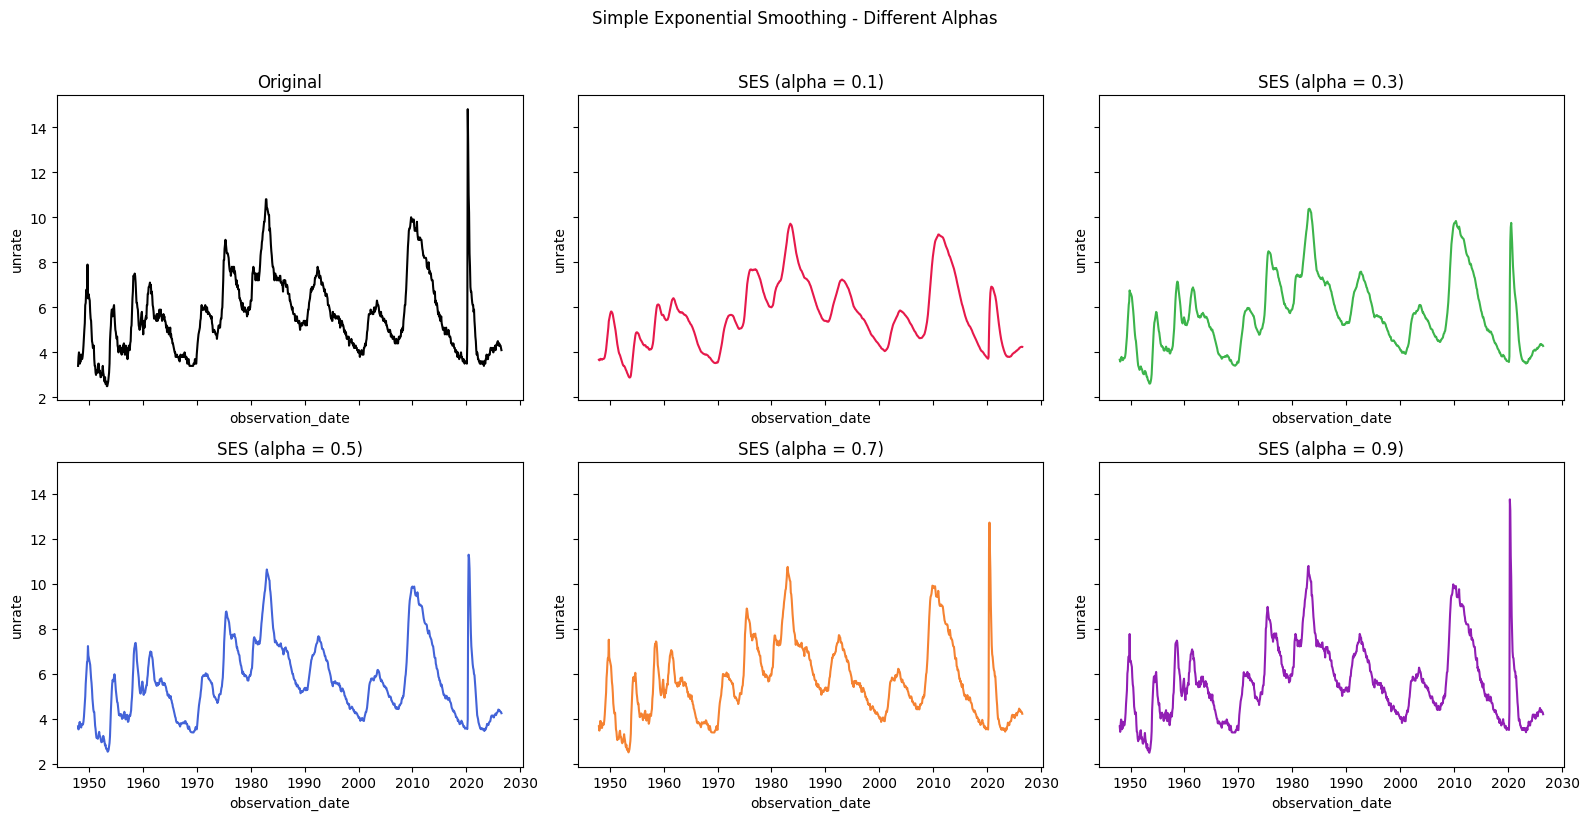

In [607]:
alphas = [0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.flatten()

# First subplot: original series
axes[0].plot(dataset["unrate"], color="black")
axes[0].set_title("Original")

colors = ["#e6194B", "#3cb44b", "#4363d8", "#f58231", "#911eb4"]

for ax, alpha, color in zip(axes[1:], alphas, colors):
    ses_model = SimpleExpSmoothing(dataset["unrate"], initialization_method="estimated")
    ses_fit = ses_model.fit(smoothing_level=alpha, optimized=False)
    ses_smoothed = ses_fit.fittedvalues

    ax.plot(ses_smoothed, color=color)
    ax.set_title(f"SES (alpha = {alpha})")

for ax in axes:
    ax.set_xlabel(dataset.index.name if dataset.index.name else "Date")
    ax.set_ylabel("unrate")

fig.suptitle("Simple Exponential Smoothing - Different Alphas", y=1.02)
plt.tight_layout()
plt.show()

### What the smoothing reveals

- **Moving averages**: As the window size increases (10 → 200), the series gets progressively flatter and the recession spikes get wider and shallower. Small windows (10, 20) still track the shape of individual recessions fairly closely, while large windows (100, 200) collapse decades of cyclical ups and downs into one long, slow-moving curve. This shows that most of the series' movement is short-to-medium-term cyclical behavior (recessions and recoveries), not a persistent long-run trend — once you average over a long enough window, that cyclicality washes out and what's left is close to a flat, slowly-drifting line.

- **Simple Exponential Smoothing**: As alpha increases (0.1 → 0.9), the smoothed line hugs the original series more and more closely, reacting almost immediately to new observations. Low alpha (0.1) produces a heavily lagged, very smooth line that barely reacts to spikes, while high alpha (0.9) is nearly identical to the raw data. This illustrates the trade-off SES makes between recent responsiveness and noise suppression: it can either track the series closely (high alpha) or filter out noise (low alpha), but not both — and unlike moving averages, it does this using an exponentially decaying weight on the past rather than a hard cutoff window.

Together, both methods confirm the same underlying structure identified earlier: no seasonality, no strong secular trend, but strong cyclical/shock-driven behavior around a fairly stable baseline level.

### Information lost due to smoothing

- **Timing/turning points**: Both methods lag real turning points — moving averages more so with larger windows, SES more so with smaller alphas. This means the smoothed series understates how fast the unemployment rate actually rose during a recession's onset, and it shows the *peak* of a recession later and lower than it really occurred.
- **Magnitude of shocks**: Sharp spikes (e.g., the COVID-era jump) get flattened — the true peak value is understated the more aggressive the smoothing is (large window / low alpha).
- **Short-term volatility**: Month-to-month fluctuations are deliberately removed, so any short-term signal (e.g., a one-off data anomaly, or an early warning of a turning point) is lost along with the noise.
- **Edge data**: Moving averages additionally lose the first `window-1` observations entirely (NaNs), so long windows sacrifice usable history at the start of the series.

In short: smoothing trades off responsiveness/detail for a clearer view of the underlying level, and heavier smoothing (larger window or lower alpha) always costs more in timing accuracy and shock magnitude.